## 4. Evaluation

### 4.1 Importing the Library

In [15]:
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.models import load_model

In [16]:
DATA_DIR = "../dataset/processed"
MODEL_DIR = "models"

### 4.2 Load the Data

In [17]:
X_test_tfidf  = pickle.load(open(os.path.join(DATA_DIR, "X_test_tfidf.pkl"), "rb"))
X_test_pad    = pickle.load(open(os.path.join(DATA_DIR, "X_test_pad.pkl"), "rb"))
y_test        = pickle.load(open(os.path.join(DATA_DIR, "y_test.pkl"), "rb"))

### 4.3 Check Array Dimension

In [18]:
y_test_sklearn = y_test.astype(int).ravel()

### 4.4 Load Models

In [19]:
rf_model     = pickle.load(open(os.path.join(MODEL_DIR, "rf_model.pkl"), "rb"))
lstm_model   = load_model(os.path.join(MODEL_DIR, "lstm_model.keras"))
bilstm_model = load_model(os.path.join(MODEL_DIR, "bilstm_model.keras"))

### 4.5 Evaluating Function

In [20]:
def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"Akurasi : {acc:.4f}")
    # y_true di sini harus y_test_sklearn
    print(classification_report(y_true, y_pred))
    return acc

### 4.6 Predicting and Evaluate All Models

In [21]:
scores = {}

# rf x tfidf
rf_pred = rf_model.predict(X_test_tfidf)
scores['Random Forest (TF-IDF)'] = evaluate_model("Random Forest (TF-IDF)", y_test_sklearn, rf_pred)


# lstm x tfidf
lstm_pred_prob = lstm_model.predict([X_test_pad, X_test_tfidf])
lstm_pred = (lstm_pred_prob > 0.5).astype(int).ravel() 
scores['LSTM + TF-IDF'] = evaluate_model("LSTM + TF-IDF", y_test_sklearn, lstm_pred)


# bilstm x tfidf
bilstm_pred_prob = bilstm_model.predict([X_test_pad, X_test_tfidf])
bilstm_pred = (bilstm_pred_prob > 0.5).astype(int).ravel()
scores['BiLSTM + TF-IDF'] = evaluate_model("BiLSTM + TF-IDF", y_test_sklearn, bilstm_pred)

[Parallel(n_jobs=22)]: Using backend ThreadingBackend with 22 concurrent workers.
[Parallel(n_jobs=22)]: Done   6 tasks      | elapsed:    0.0s
[Parallel(n_jobs=22)]: Done 100 out of 100 | elapsed:    0.0s finished


Akurasi : 0.9668
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       316
           1       0.97      0.97      0.97       316

    accuracy                           0.97       632
   macro avg       0.97      0.97      0.97       632
weighted avg       0.97      0.97      0.97       632

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
Akurasi : 0.9668
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       316
           1       0.97      0.97      0.97       316

    accuracy                           0.97       632
   macro avg       0.97      0.97      0.97       632
weighted avg       0.97      0.97      0.97       632

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step
Akurasi : 0.9620
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       316
           1       0.97      0.95      0.96       316

    accuracy                           0.96       6

In [23]:
scores

{'Random Forest (TF-IDF)': 0.9667721518987342,
 'LSTM + TF-IDF': 0.9667721518987342,
 'BiLSTM + TF-IDF': 0.9620253164556962}

### 4.7 Visualizing

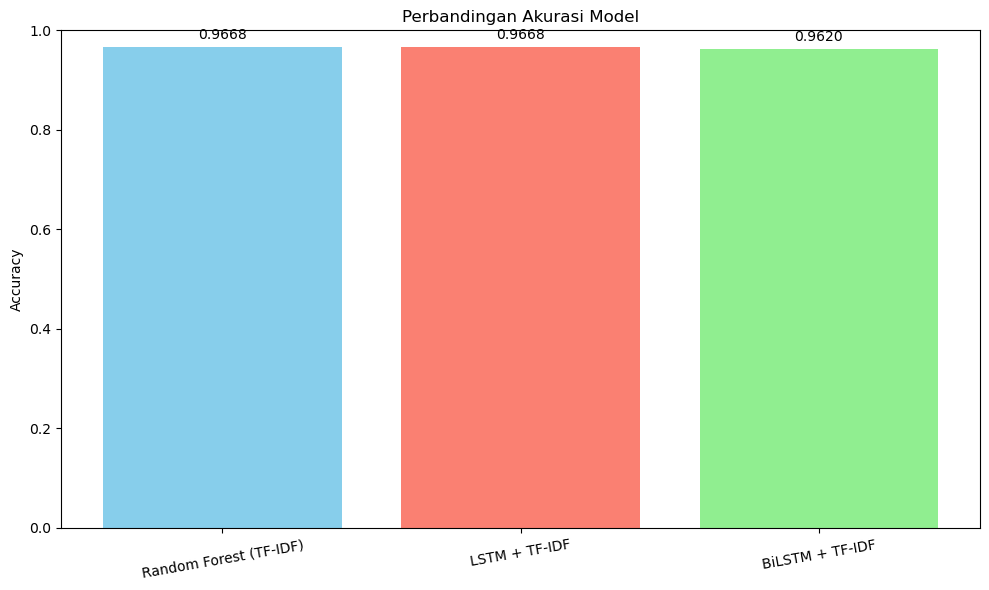

In [ ]:
plt.figure(figsize=(10, 6))
bars = plt.bar(scores.keys(), scores.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.xticks(rotation=10) # Rotasi sedikit saja cukup
plt.ylabel("Accuracy")
plt.title("Perbandingan Akurasi Model")
plt.ylim(0, 1.0) # Set batas Y dari 0.0 sampai 1.0

# Tambahkan label angka di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.01, f'{yval:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()